In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 59.4 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
# pandas print option
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)

In [ ]:
# Canonical SMILES Function
def to_canonical(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Chem.MolToSmiles(mol, canonical=True)
    else:
        return None

In [ ]:
# Data
df = pd.read_csv('data/fluorclass_dataset.csv',encoding='utf-8-sig')
display(df)

,SMILES,Class
0,Nc1c(/N=N/c2ccc([N+](=O)[O-])cc2)c(S(=O)(=O)[O][Na])cc2c1C(=O)/C(=N\Nc1ccccc1)C(S(=O)(=O)[O][Na])=C2,0
1,Nc1c(/N=N/c2ccc(S(=O)(=O)[O][Na])cc2)cc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1ccc([N+](=O)[O-])cc1)C=C2,0
2,Nc1c(/N=N/c2ccc(S(=O)(=O)[O][Na])cc2)cc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1cccc3ccccc13)C=C2,0
3,O=[N+]([O-])c1ccc2c(/N=N/c3c(O)ccc4ccccc34)c(O)cc(S(=O)(=O)[O][Na])c2c1,0
4,Nc1ccc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1ccc(/N=N/c3ccc(S(=O)(=O)[O][Na])cc3)c3ccccc13)C(S(=O)(=O)[O][Na])=C2,0
...,...,...
5461,CN(C)c1ccc(-c2ccc3c(=O)c(O)coc3c2)cc1,1
5462,COc1coc2cc(-c3ccc(N(C)C)cc3)ccc2c1=O,1
5463,COC(=O)CN1C(=O)c2cc3ccc(N(C)C)cc3cc2C1=O,1
5464,CCN(CC)c1ccc2c(c1)C(C)(C)c1cc(C=O)ccc1-2,1


In [ ]:
smiles_list = df['SMILES'].tolist()
labels = df['Class'].values
indices = df.index.tolist()

In [ ]:
from rdkit.Chem import rdFingerprintGenerator

# Morgan Fingerprint (ECFP) based Feature Extraction ---------------------------

# SMILES to ECFP Function
def smiles_to_fingerprint(smiles, radius=4, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    if mol:
        return list(fpgen.GetFingerprint(mol))
    else:
        return [0] * n_bits  # return to zero vector on conversion failure

# Convert SMILES to ECFP and Numpy array
X = np.array([smiles_to_fingerprint(smiles) for smiles in smiles_list])
y = np.array(labels)

# Check
print(f"\nMorgan Fingerprints Feature Shape (2048 bits): {X.shape}")
print(f"Labels Shape: {y.shape}")
df_X = pd.DataFrame(X, columns=[f'bit_{i}' for i in range(X.shape[1])])
display(df_X)


Morgan Fingerprints Feature Shape (2048 bits): (5466, 2048)
Labels Shape: (5466,)


,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_2038,bit_2039,bit_2040,bit_2041,bit_2042,bit_2043,bit_2044,bit_2045,bit_2046,bit_2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5461,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
5462,0,0,0,0,0,0,0,0,1,0,...,0,0,1,1,0,0,0,0,0,0
5463,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5464,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# Load saved files
mol_table = pd.read_csv("result/04_Interpretation/mol_table.csv")
ig_matrix_raw = np.load("result/04_Interpretation/ig_matrix_raw.npy")
ig_long_table = pd.read_csv("result/04_Interpretation/ig_long_table.csv")

# Check
print("mol_table shape:", mol_table.shape)
print("ig_matrix_raw shape:", ig_matrix_raw.shape)
print("ig_long_table shape:", ig_long_table.shape)

display(mol_table.head())
display(ig_long_table.head())
print(ig_matrix_raw[:3, :5])

mol_table shape: (5466, 6)
ig_matrix_raw shape: (5466, 2048)
ig_long_table shape: (467571, 6)


,mol_id,SMILES,y_true,y_pred_label,correct,onbit_count
0,0,Nc1c(/N=N/c2ccc([N+](=O)[O-])cc2)c(S(=O)(=O)[O][Na])cc2c1C(=O)/C(=N\Nc1ccccc1)C(S(=O)(=O)[O][Na])=C2,0,0,True,105
1,1,Nc1c(/N=N/c2ccc(S(=O)(=O)[O][Na])cc2)cc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1ccc([N+](=O)[O-])cc1)C=C2,0,0,True,105
2,2,Nc1c(/N=N/c2ccc(S(=O)(=O)[O][Na])cc2)cc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1cccc3ccccc13)C=C2,0,0,True,110
3,3,O=[N+]([O-])c1ccc2c(/N=N/c3c(O)ccc4ccccc34)c(O)cc(S(=O)(=O)[O][Na])c2c1,0,0,True,87
4,4,Nc1ccc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1ccc(/N=N/c3ccc(S(=O)(=O)[O][Na])cc3)c3ccccc13)C(S(=O)(=O)[O][Na])=C2,0,0,True,112


,mol_id,y_true,bit,ig_raw,ig_abs,ig_direction
0,0,0,84,-0.000389,0.000389,-1
1,0,0,111,0.004322,0.004322,1
2,0,0,150,0.007691,0.007691,1
3,0,0,186,-0.015012,0.015012,-1
4,0,0,191,-0.015747,0.015747,-1


[[-0. -0. -0.  0.  0.]
 [-0. -0. -0.  0.  0.]
 [-0. -0.  0.  0.  0.]]


In [ ]:
bit_stats = ig_long_table.groupby("bit").agg(
    freq=("mol_id", "nunique"),
    mean_ig=("ig_raw", "mean"),
    mean_abs=("ig_abs", "mean"),
    std_ig=("ig_raw", "std"),
    pos_count=("ig_direction", lambda x: (x > 0).sum()),
    neg_count=("ig_direction", lambda x: (x < 0).sum()),
    pos_rate=("ig_direction", lambda x: (x > 0).mean()),
    neg_rate=("ig_direction", lambda x: (x < 0).mean())
).reset_index()

display(bit_stats)

,bit,freq,mean_ig,mean_abs,std_ig,pos_count,neg_count,pos_rate,neg_rate
0,0,64,-0.004462,0.004462,0.003686,0,64,0.000000,1.000000
1,1,550,-0.006735,0.006737,0.003341,1,549,0.001818,0.998182
2,2,216,0.009759,0.009788,0.006028,212,4,0.981481,0.018519
3,3,125,0.026840,0.026840,0.013807,125,0,1.000000,0.000000
4,4,131,0.016328,0.016328,0.009778,131,0,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...
2043,2043,194,-0.000415,0.002264,0.002774,95,99,0.489691,0.510309
2044,2044,176,-0.016625,0.016625,0.010263,0,176,0.000000,1.000000
2045,2045,87,0.012897,0.012897,0.006676,87,0,1.000000,0.000000
2046,2046,89,-0.006091,0.006091,0.004328,0,89,0.000000,1.000000


In [ ]:
bit_stats_sorted_by_mean = bit_stats.sort_values(
    by="mean_ig",
    ascending=False
).reset_index(drop=True)

display(bit_stats_sorted_by_mean)

,bit,freq,mean_ig,mean_abs,std_ig,pos_count,neg_count,pos_rate,neg_rate
0,941,76,0.068087,0.068087,0.041367,76,0,1.0,0.0
1,430,141,0.057398,0.057398,0.033702,141,0,1.0,0.0
2,1126,106,0.057077,0.057077,0.036178,106,0,1.0,0.0
3,570,99,0.053706,0.053706,0.031880,99,0,1.0,0.0
4,472,126,0.049328,0.049328,0.025855,126,0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
2043,1476,2338,-0.042425,0.042425,0.025782,0,2338,0.0,1.0
2044,804,104,-0.043473,0.043473,0.026704,0,104,0.0,1.0
2045,504,182,-0.055135,0.055135,0.031579,0,182,0.0,1.0
2046,1866,379,-0.066937,0.066937,0.045438,0,379,0.0,1.0


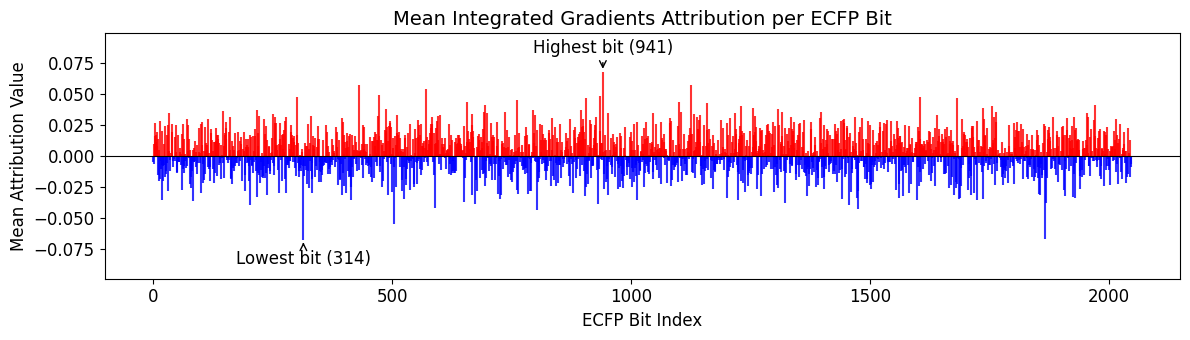

In [ ]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# Sort by bit
bit_stats_sorted = bit_stats.sort_values("bit")

mean_ig_vector = bit_stats_sorted["mean_ig"].values
x = np.arange(len(mean_ig_vector))

plt.figure(figsize=(12, 3.5))

pos_idx = mean_ig_vector > 0
neg_idx = mean_ig_vector < 0
zero_idx = mean_ig_vector == 0

# Positive
plt.vlines(x[pos_idx], 0, mean_ig_vector[pos_idx],
           color='red', alpha=0.8, linewidth=1.5)

# Negative
plt.vlines(x[neg_idx], 0, mean_ig_vector[neg_idx],
           color='blue', alpha=0.8, linewidth=1.5)

# Near Zero
plt.scatter(x[zero_idx],
            np.zeros_like(x[zero_idx]),
            color='#6A0DAD', s=2, alpha=0.6)

plt.axhline(0, color='black', linewidth=0.8)

# -----------------------------
# Find highest / lowest bit
# -----------------------------
max_idx = np.argmax(mean_ig_vector)
min_idx = np.argmin(mean_ig_vector)

max_val = mean_ig_vector[max_idx]
min_val = mean_ig_vector[min_idx]

# highest bit
plt.annotate(f"Highest bit ({max_idx})",
             xy=(max_idx, max_val),
             xytext=(max_idx, max_val + 0.015),
             arrowprops=dict(arrowstyle="->", color="black"),
             ha='center',
             fontsize=12)

# lowest bit
plt.annotate(f"Lowest bit ({min_idx})",
             xy=(min_idx, min_val),
             xytext=(min_idx, min_val - 0.02),
             arrowprops=dict(arrowstyle="->", color="black"),
             ha='center',
             fontsize=12)

plt.title("Mean Integrated Gradients Attribution per ECFP Bit", fontsize=14)
plt.xlabel("ECFP Bit Index", fontsize=12)
plt.ylabel("Mean Attribution Value", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(-0.099, 0.099)

plt.tight_layout()
plt.savefig("result/05_DrawGraph/Global_meanIG_bar_point.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
def plot_zoom_bit_clean(mean_ig_vector,
                        center_bit,
                        window=10,
                        ylim=None,
                        label_size=12,
                        tick_size=11,
                        save_name=None,
                        dpi=600):

    start = max(0, center_bit - window)
    end = min(len(mean_ig_vector), center_bit + window + 1)

    zoom_vals = mean_ig_vector[start:end]

    x = np.linspace(0, len(zoom_vals)-1, len(zoom_vals))

    plt.figure(figsize=(6, 3))

    pos_idx = zoom_vals > 0
    neg_idx = zoom_vals < 0

    plt.vlines(x[pos_idx], 0, zoom_vals[pos_idx],
               color='red', linewidth=2)

    plt.vlines(x[neg_idx], 0, zoom_vals[neg_idx],
               color='blue', linewidth=2)

    center_pos = center_bit - start

    plt.scatter(
        x[center_pos],
        zoom_vals[center_pos],
        color='black',
        s=30,
        zorder=5
    )

    plt.axhline(0, color='black', linewidth=0.8)

    plt.xticks(
    [x[0], x[center_pos], x[-1]],
    [f"Bit {start}", f"Bit {center_bit}", f"Bit {end-1}"],
    fontsize=tick_size
)

    plt.ylabel(
        "Mean Attribution Value",
        fontsize=label_size
    )

    plt.yticks(fontsize=tick_size)

    if ylim is not None:
        plt.ylim(ylim)

    plt.tight_layout()
    if save_name is not None:
        plt.savefig(save_name, dpi=dpi, bbox_inches="tight")
        print(f"Saved: {save_name}")
    plt.show()

Saved: Zoom_highest_bit_941.png


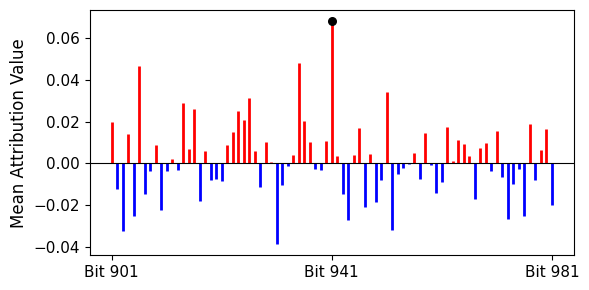

In [ ]:
# highest
plot_zoom_bit_clean(mean_ig_vector, center_bit=max_idx, window=40, save_name="result/05_DrawGraph/Zoom_highest_bit_941.png")


Saved: Zoom_lowest_bit_314.png


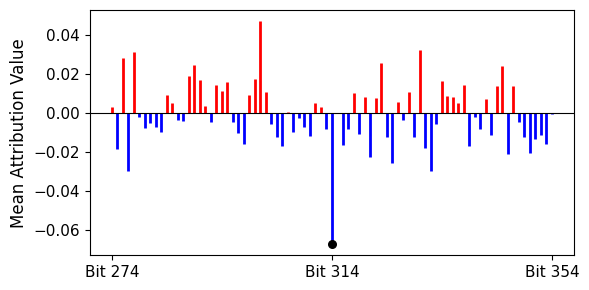

In [ ]:
# lowest
plot_zoom_bit_clean(mean_ig_vector, center_bit=min_idx, window=40, save_name="result/05_DrawGraph/Zoom_lowest_bit_314.png")